In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr

## Download Forecasts - Earthkit

Use form `https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels?tab=download` to check request attributes.

In [2]:
import earthkit.data as ekd
import rioxarray as xrio
import xarray as xr


In [3]:
import logging

# Silence the verbose "Request ID"/"status has been updated" polling messages
logging.getLogger("cdsapi").setLevel(logging.WARNING)
logging.getLogger("ecmwf.datastores").setLevel(logging.WARNING)

# Persist downloads to a local folder instead of an unmanaged temp dir, so
# files are kept on disk and reused (no re-download) across sessions.
# ekd.config.set("cache-policy", "user")
# ekd.config.set("user-cache-directory", "/data/CN3S/forecasts")


In [4]:
models = {
    "UKMO GloaSea6-GC5.1": {"originating_centre": "ukmo", "system": "610"},
    "ECMWF SEAS5": {"originating_centre": "ecmwf", "system": "51"},
    "Meteo France S9": {"originating_centre": "meteo_france", "system": "9"},
    "DWD GCFS2.2": {"originating_centre": "dwd", "system": "22"},
    "CMCC SPS4": {"originating_centre": "cmcc", "system": "4"},
    "NCEP CFSv2": {"originating_centre": "ncep", "system": "2"},
    "JMA CPS4": {"originating_centre": "jma", "system": "4"},
    "ECCC GEM5.2-NEMO": {"originating_centre": "eccc", "system": "5"},
    "BOM ACCESS-S2": {"originating_centre": "bom", "system": "2"},
}


In [5]:
data = {}

request = {
    "variable": ["total_precipitation"],
    "product_type": [
        "ensemble_mean",
        # "hindcast_climate_mean",
        # "monthly_mean",
        # "monthly_standard_deviation",
    ],
    "year": ["2026"],
    "month": ["09"],
    "leadtime_month": ["2", "3", "4"],
    "area": [6, -75, -35, -34],  # Brazil bbox: North, West, South, East
    "data_format": "grib",
}

for model_name, model_request in models.items():
    request.update(model_request)

    data[model_name] = ekd.from_source(
        "cds",
        "seasonal-monthly-single-levels",
        request=request,
    )


2026-10-01 19:13:52,282 INFO Request ID is 0f7ba8a4-6e46-4ce7-a5b2-299c55ee5d65
2026-10-01 19:13:52,504 INFO status has been updated to successful


b38845fe9a90d215f5c39053aeb566a.grib:   0%|          | 0.00/10.2k [00:00<?, ?B/s]

2026-10-01 19:13:59,580 INFO Request ID is 6afe6274-c969-4af3-86b2-6d8ce6ca2a1f
2026-10-01 19:13:59,801 INFO status has been updated to successful


20fcbcbf3cf288a169a1e1d5c31950a3.grib:   0%|          | 0.00/10.2k [00:00<?, ?B/s]

2026-10-01 19:14:03,016 INFO Request ID is f357f9c0-8da9-47b7-92d2-c4a594d4c7e4
2026-10-01 19:14:03,257 INFO status has been updated to successful


...

23568b8fc754406622b54775a82c5eb5.grib:   0%|          | 0.00/6.78k [00:00<?, ?B/s]

2026-10-01 19:14:27,007 INFO Request ID is a5fe7893-bc20-4404-86be-47fa0ef32010
2026-10-01 19:14:27,234 INFO status has been updated to successful


8415bc4b7ddbdbf788f46541d622b318.grib:   0%|          | 0.00/15.2k [00:00<?, ?B/s]

2026-10-01 19:14:30,574 INFO Request ID is 682ae71b-4e52-4db7-8a44-c8d9d82e0fa4
2026-10-01 19:14:30,783 INFO status has been updated to successful


ea3719f539f490c7597165a3fd78c059.grib:   0%|          | 0.00/10.2k [00:00<?, ?B/s]

In [7]:
for model_name, gribdata in data.items():
    array = gribdata.to_xarray()
    array.rio.write_crs("epsg:4326")

    model_shortname = models[model_name]["originating_centre"]
    path = f"/data/CN3S/forecasts/prec/{model_shortname}_202609.nc2"

    print(f"Saving {model_name}: {path}")
    array.to_netcdf(path, engine="netcdf4")


Saving UKMO GloaSea6-GC5.1: /data/CN3S/forecasts/prec/ukmo_202609.nc2
Saving ECMWF SEAS5: /data/CN3S/forecasts/prec/ecmwf_202609.nc2
Saving Meteo France S9: /data/CN3S/forecasts/prec/meteo_france_202609.nc2
Saving DWD GCFS2.2: /data/CN3S/forecasts/prec/dwd_202609.nc2
Saving CMCC SPS4: /data/CN3S/forecasts/prec/cmcc_202609.nc2
Saving NCEP CFSv2: /data/CN3S/forecasts/prec/ncep_202609.nc2
Saving JMA CPS4: /data/CN3S/forecasts/prec/jma_202609.nc2
Saving ECCC GEM5.2-NEMO: /data/CN3S/forecasts/prec/eccc_202609.nc2
Saving BOM ACCESS-S2: /data/CN3S/forecasts/prec/bom_202609.nc2


In [9]:
# data.to_xarray().compute()

In [10]:
convert = 1000 * 30 * 24 * 60 * 60  # convert from m.s-1 to mm/month
# prec_fcst = data.to_xarray()["tprate"].mean(dim="member") * convert

In [11]:
# prec_fcst.isel(step=0).plot()

In [12]:
# prec_fcst = prec_fcst.rio.write_crs("epsg:4326")

## Calculate Forecast Cube

In [16]:
convert = 1000 * 30 * 24 * 60 * 60  # convert from m.s-1 to mm/month

# Read the arrays
arrays = []
for i, model_name in enumerate(models):
    ds = xr.open_dataset(
        f"/data/CN3S/forecasts/prec/{models[model_name]['originating_centre']}_202609.nc2",
    )

    # Calculate the total precipitation
    arr = ds["tprate"].rename(models[model_name]["originating_centre"]) * convert

    if i == 0:
        ref_latitude = ds.latitude
        ref_longitude = ds.longitude
    else:
        arr = arr.interp(latitude=ref_latitude, longitude=ref_longitude)

    arrays.append(arr)


[autoreload of scipy.interpolate._fitpack_impl failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 121, in reload
    raise ImportError(f"parent {parent_name!r} not in sys.modules",
ImportError: parent 'scipy.interpolate' not in sys.modules
]
[autoreload of scipy.optimize._dcsrch failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File

In [17]:
for array in arrays:
    print(array.name, array.shape)

ukmo (3, 41, 41)
ecmwf (3, 41, 41)
meteo_france (3, 41, 41)
dwd (3, 41, 41)
cmcc (3, 41, 41)
ncep (3, 41, 41)
jma (3, 41, 41)
eccc (3, 41, 41)
bom (3, 41, 41)


In [18]:
prec_fcst = xr.concat(arrays, dim="model").rename("models").rio.write_crs("epsg:4326")

In [19]:
prec_fcst

<xarray.DataArray 'models' (model: 9, step: 3, latitude: 41, longitude: 41)> Size: 363kB
array([[[[577.17027725, 326.96418115, 176.08992407, ..., 376.60181174,
          386.76696481, 402.0807019 ],
         [259.14620259, 192.29004742, 118.19192791, ..., 272.91347855,
          281.87163757, 298.12833877],
         [218.12726395, 147.36723737, 111.06311926, ..., 165.03838473,
          175.44870847, 190.06465213],
         ...,
         [ 14.57903185,  14.71104683,  16.82328643, ..., 147.63126732,
          149.81894405, 153.7793933 ],
         [ 19.65217875,  21.10434347,  24.25384359, ..., 147.98959368,
          149.78122549, 152.77985135],
         [ 23.31087948,  29.64759828,  40.00134417, ..., 141.70945273,
          144.74579716, 149.91324046]],

        [[401.14108125, 198.4980947 ,  93.99881238, ..., 310.39021561,
          313.95461993, 323.40312028],
         [162.64659936,  97.48777958,  43.81426262, ..., 366.55315781,
          389.93866766, 410.53300375],
         [125.53153211,  67.95414375,  46.60543637, ..., 333.11565058,
          357.19895387, 388.12817657],
...
         [ 11.09151523,  12.75113206,  19.95537784, ..., 193.59278846,
          199.13741741, 196.11993227],
         [ 14.41074889,  17.03218911,  25.8017553 , ..., 165.71876947,
          173.48879371, 176.37426387],
         [ 19.0501323 ,  24.63247981,  46.20749857, ..., 147.16123585,
          150.53704735, 158.02418236]],

        [[106.16096914,  84.69910607,  45.75468846, ..., 340.1480826 ,
          334.07539376, 333.54733386],
         [ 86.50959716,  54.12820973,  32.47775384, ..., 365.94758057,
          364.92917933, 361.77967921],
         [ 81.7193395 ,  44.26480517,  44.79286507, ..., 299.07256611,
          297.09234149, 289.98239212],
         ...,
         [  2.90639945,   1.81256109,   3.4910372 , ..., 252.94276201,
          260.16586707, 249.39721697],
         [  6.24449239,   4.30198633,   4.60373484, ..., 224.48410526,
          234.17777628, 241.70262985],
         [  7.30061219,   8.03612419,  10.33695661, ..., 207.64276632,
          211.09401495, 214.63955999]]]], shape=(9, 3, 41, 41))
Coordinates:
  * step         (step) timedelta64[ns] 24B 61 days 91 days 122 days
  * latitude     (latitude) float64 328B 5.5 4.5 3.5 2.5 ... -32.5 -33.5 -34.5
  * longitude    (longitude) float64 328B -74.5 -73.5 -72.5 ... -35.5 -34.5
    spatial_ref  int64 8B 0
Dimensions without coordinates: model
Attributes:
    long_name:   Time-mean total precipitation rate
    units:       meter / second
    level_type:  surface
    _earthkit:   {"message": {"__bytes_b64__": "R1JJQgAAiAEAAFCsSoD/gOQBAAAaC...

## Load basin and monthly precipitation

In [ ]:
import logging

import geopandas as gpd
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import DownloadMode, FileDownloader
from mergedownloader.inpeparser import InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

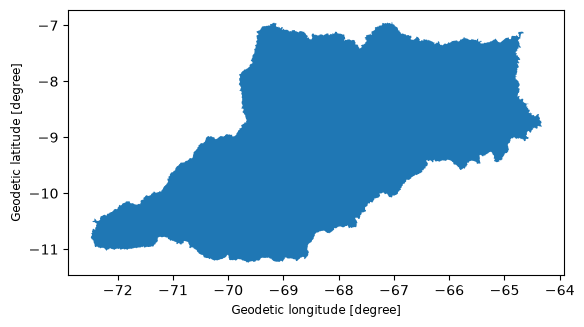

In [21]:
basin = gpd.read_parquet("/data/CN3S/stations/13870000/watershed.parquet")
# basin = gpd.read_file("/data/Geospatial_BR_Data/Amazonia/LIMITERAISG.shp")
basin.plot()

In [22]:
fd = FileDownloader(
    download_mode=DownloadMode.NO_UPDATE,
    log_level=logging.DEBUG,
)

downloader = Downloader(
    file_downloader=fd,
    local_folder="/data/CN3S/downloads",
    parsers=InpeParsers,
    log_level=logging.DEBUG,
)

Using HTTP downloads


In [23]:
import pandas as pd

In [24]:
today = pd.Timestamp.now()

In [25]:
obs_range = pd.date_range(
    start=today - pd.DateOffset(months=13),
    end=today,
    freq="MS",
    normalize=True,
)
avg_range = pd.date_range(
    start=today - pd.DateOffset(months=13),
    end=today + pd.DateOffset(months=2),
    freq="MS",
    normalize=True,
)

In [87]:
prec_avg = downloader.create_cube(
    avg_range[0].to_pydatetime(),
    avg_range[-1].to_pydatetime(),
    InpeTypes.MONTHLY_ACCUM,
)

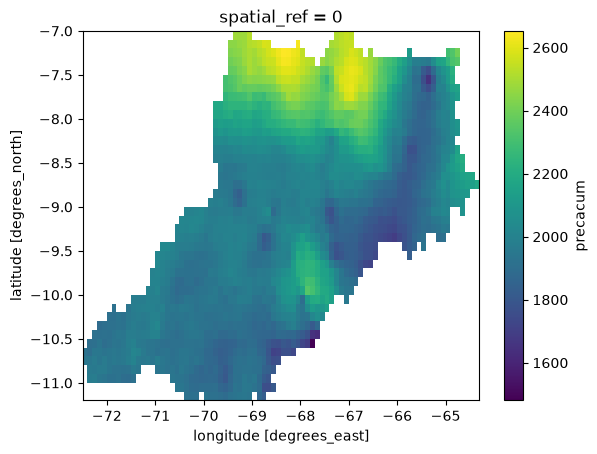

In [97]:
prec_avg.sum(dim="time").rio.clip(basin.geometry).plot()

In [27]:
prec_obs = downloader.create_cube(
    obs_range[0].to_pydatetime(),
    obs_range[-1].to_pydatetime(),
    InpeTypes.MONTHLY_ACCUM_MANUAL,
)

/usr/local/lib/python3.12/dist-packages/mergedownloader/inpeparser.py:469: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  cube = xr.concat(dependencies[InpeTypes.DAILY_RAIN], dim="time")
/usr/local/lib/python3.12/dist-packages/mergedownloader/inpeparser.py:469: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  cube = 

In [103]:
prec_obs["longitude"] = prec_obs["longitude"] + 360

In [105]:
prec_avg = GISUtil.cut_cube_by_geoms(prec_avg, basin.geometry)


In [106]:
prec_obs = GISUtil.cut_cube_by_geoms(prec_obs, basin.geometry)


In [107]:
prec_fcst = GISUtil.cut_cube_by_geoms(prec_fcst, basin.geometry)

In [108]:
prec_avg["time"] = avg_range
prec_avg_mean = prec_avg.mean(dim=["longitude", "latitude"])
prec_obs_mean = prec_obs.mean(dim=["longitude", "latitude"])


# Keep the per-model spatial mean (model dim preserved) to inspect dispersion laterprec_fcst_mean = prec_fcst_by_model.mean(dim="model")

prec_fcst_by_model = prec_fcst.mean(dim=["longitude", "latitude"])
prec_fcst_by_model["model"] = list(models.keys())

prec_fcst_mean = prec_fcst_by_model.mean(dim="model")

In [109]:
prec_fcst_mean["step"] = prec_avg["time"].to_numpy()[-3:]
prec_fcst_by_model["step"] = prec_fcst_mean["step"]

## Total Precipitation Charts

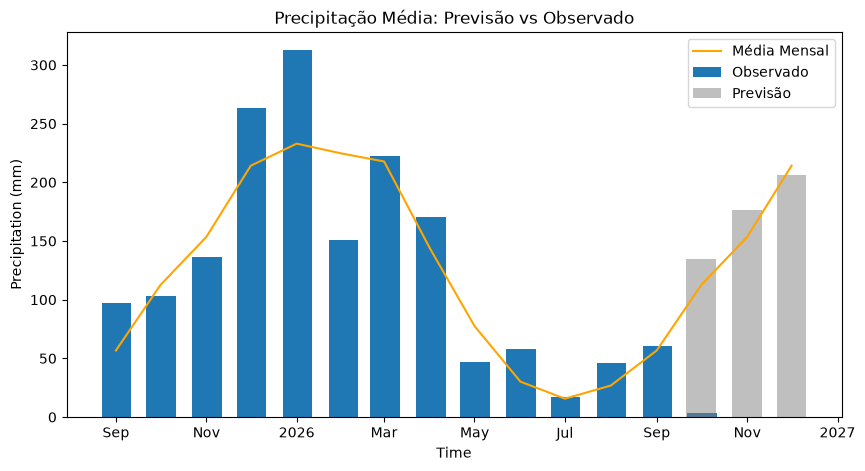

In [110]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
prec_avg_mean.plot(ax=ax, label="Média Mensal", color="orange")
ax.bar(prec_obs_mean["time"], prec_obs_mean, width=20.0, label="Observado")

ax.bar(
    prec_fcst_mean["step"], prec_fcst_mean, width=20.0, label="Previsão", alpha=0.5, color="grey"
)


ax.set_title("Precipitação Média: Previsão vs Observado")
ax.set_xlabel("Time")
ax.set_ylabel("Precipitation (mm)")

ax.legend()

/tmp/ipykernel_44344/2043019843.py:20: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  tick_halfwidth = pd.Timedelta(days=9)


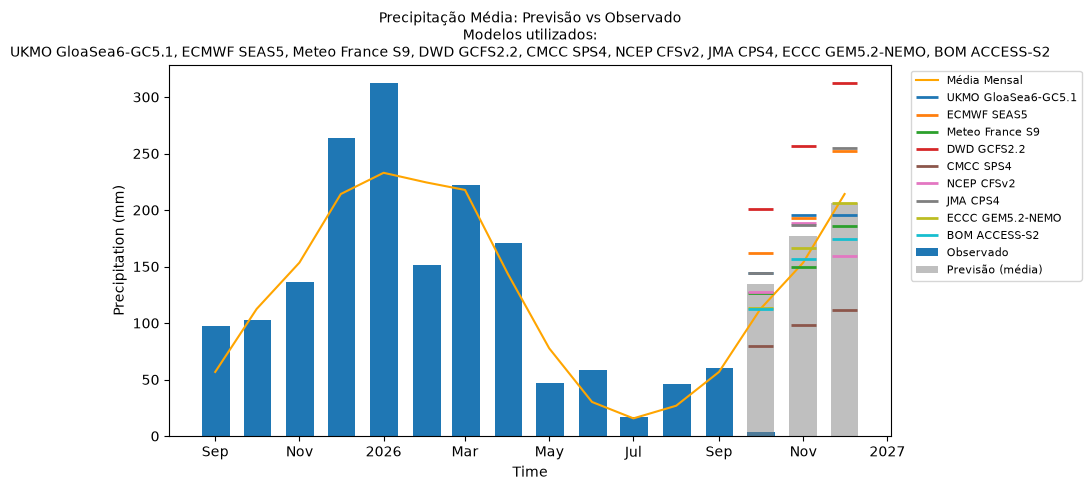

In [111]:
import matplotlib.pyplot as plt

model_names = list(models.keys())
model_colors = plt.get_cmap("tab10", len(model_names))

fig, ax = plt.subplots(figsize=(10, 5))
prec_avg_mean.plot(ax=ax, label="Média Mensal", color="orange")
ax.bar(prec_obs_mean["time"], prec_obs_mean, width=20.0, label="Observado")
ax.bar(
    prec_fcst_mean["step"],
    prec_fcst_mean,
    width=20.0,
    label="Previsão (média)",
    alpha=0.5,
    color="grey",
)

# Overlay each model's individual forecast as a short horizontal tick on the forecast bars,
# so the dispersion/range across models is visible at each lead time.
tick_halfwidth = pd.Timedelta(days=9)
steps = prec_fcst_by_model["step"].to_numpy()
for i, model_name in enumerate(model_names):
    model_values = prec_fcst_by_model.sel(model=model_name).to_numpy()
    for j, (step, value) in enumerate(zip(steps, model_values)):
        ax.hlines(
            value,
            xmin=step - tick_halfwidth,
            xmax=step + tick_halfwidth,
            color=model_colors(i),
            linewidth=2,
            label=model_name if j == 0 else None,
        )

model_list_str = ", ".join(model_names)
ax.set_title(
    f"Precipitação Média: Previsão vs Observado\nModelos utilizados:\n{model_list_str}",
    fontsize=10,
)
ax.set_xlabel("Time")
ax.set_ylabel("Precipitation (mm)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
fig.tight_layout()


## Anomaly

In [112]:
from tqdm.auto import tqdm

In [114]:
data = {}

request = {
    "variable": ["total_precipitation_anomalous_rate_of_accumulation"],
    "product_type": [
        "ensemble_mean",
        # "hindcast_climate_mean",
        # "monthly_mean",
        # "monthly_standard_deviation",
    ],
    "year": ["2026"],
    "month": ["09"],
    "leadtime_month": ["2", "3", "4"],
    "area": [15.0, -90.0, -60.0, -30.0],  # Brazil bbox: North, West, South, East
    "data_format": "grib",
}

for model_name, model_request in tqdm(models.items(), total=len(models)):
    request.update(model_request)

    data[model_name] = ekd.from_source(
        "cds",
        "seasonal-postprocessed-single-levels",
        request=request,
    )


  0%|          | 0/9 [00:00<?, ?it/s]

2026-10-01 19:52:03,234 INFO Request ID is 9fab3cd1-8031-426b-ab07-0396b1ae6317
2026-10-01 19:52:03,453 INFO status has been updated to accepted
2026-10-01 19:52:25,567 INFO status has been updated to running
2026-10-01 19:52:37,237 INFO status has been updated to successful


3b5ff05b8979fa12c3a1abb04ae78efe.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

2026-10-01 19:52:43,312 INFO Request ID is e8845281-034d-43fb-9798-b57f207c08a4
2026-10-01 19:52:45,367 INFO status has been updated to accepted
2026-10-01 19:52:59,701 INFO status has been updated to running
2026-10-01 19:53:19,334 INFO status has been updated to successful


4862c44581a73435ddd2394d7a0d22c3.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

...

8a476f3a7f21b222d675e8f2ad16738a.grib:   0%|          | 0.00/17.9k [00:00<?, ?B/s]

2026-10-01 19:56:27,157 INFO Request ID is fbc5810f-ae94-4ac2-a99d-1e609e940f18
2026-10-01 19:56:30,279 INFO status has been updated to accepted
2026-10-01 19:56:52,387 INFO status has been updated to successful


d9fdc132df17eaf3ed0a5bc07ff05383.grib:   0%|          | 0.00/39.9k [00:00<?, ?B/s]

Recovering from HTTP error [502 Bad Gateway], attempt 1 of 500
Retrying in 120 seconds
2026-10-01 19:58:59,716 INFO Request ID is 82b7bdce-5249-4674-a14c-d7751885353a
2026-10-01 19:58:59,936 INFO status has been updated to accepted
2026-10-01 19:59:33,714 INFO status has been updated to successful


f897ae71eaf95e16fbd0485a52622411.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

In [115]:
for model_name, gribdata in tqdm(data.items()):
    array = gribdata.to_xarray()
    array = array.rio.write_crs("epsg:4326")

    model_shortname = models[model_name]["originating_centre"]
    path = f"/data/CN3S/forecasts/anomaly/{model_shortname}_prec_anomaly_202609.nc2"

    print(f"Saving {model_name}: {path}")
    array.to_netcdf(path)


  0%|          | 0/9 [00:00<?, ?it/s]

Saving UKMO GloaSea6-GC5.1: /data/CN3S/forecasts/anomaly/ukmo_prec_anomaly_202609.nc2
Saving ECMWF SEAS5: /data/CN3S/forecasts/anomaly/ecmwf_prec_anomaly_202609.nc2
Saving Meteo France S9: /data/CN3S/forecasts/anomaly/meteo_france_prec_anomaly_202609.nc2
Saving DWD GCFS2.2: /data/CN3S/forecasts/anomaly/dwd_prec_anomaly_202609.nc2
Saving CMCC SPS4: /data/CN3S/forecasts/anomaly/cmcc_prec_anomaly_202609.nc2
Saving NCEP CFSv2: /data/CN3S/forecasts/anomaly/ncep_prec_anomaly_202609.nc2
Saving JMA CPS4: /data/CN3S/forecasts/anomaly/jma_prec_anomaly_202609.nc2
Saving ECCC GEM5.2-NEMO: /data/CN3S/forecasts/anomaly/eccc_prec_anomaly_202609.nc2
Saving BOM ACCESS-S2: /data/CN3S/forecasts/anomaly/bom_prec_anomaly_202609.nc2


In [116]:
from pathlib import Path

convert = 1000 * 30 * 24 * 60 * 60  # convert from m.s-1 to mm/month

# Read the arrays
arrays = []
anomaly_path = Path("/data/CN3S/forecasts/anomaly")
for i, model_name in enumerate(models):
    centre_name = models[model_name]["originating_centre"]
    ds = xr.open_dataset(anomaly_path / f"{centre_name}_prec_anomaly_202608.nc2")

    # Calculate the total precipitation
    arr = ds["tpara"].rename(centre_name) * convert

    if i == 0:
        ref_latitude = ds.latitude
        ref_longitude = ds.longitude
    else:
        arr = arr.interp(latitude=ref_latitude, longitude=ref_longitude)

    arrays.append(arr)

In [117]:
anomaly = xr.concat(arrays, dim="model").rio.write_crs("epsg:4326")
anomaly = GISUtil.cut_cube_by_geoms(anomaly, basin.geometry)

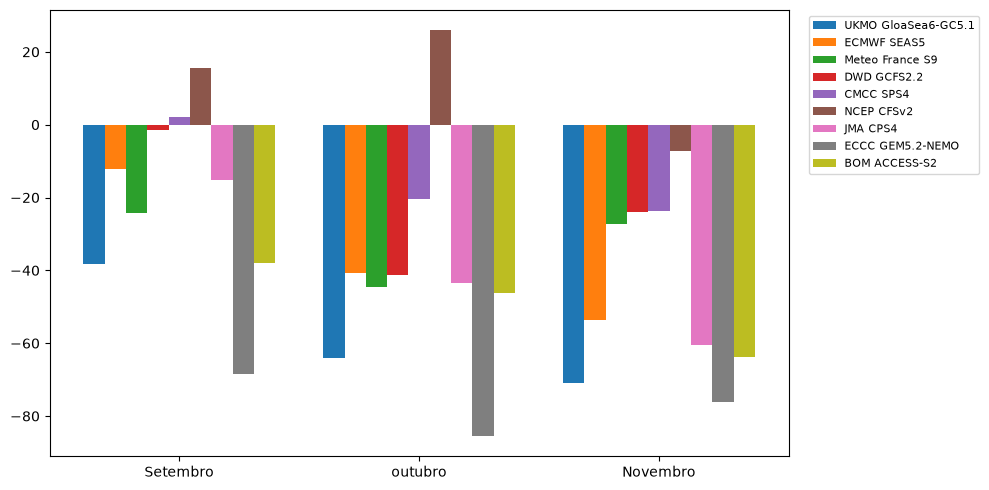

In [118]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

month_labels = ["Setembro", "outubro", "Novembro"]
x = np.arange(len(month_labels))
n_models = len(models)
bar_width = 0.8 / n_models
for i, model_name in enumerate(models):
    model_anomaly = anomaly.isel(model=i)
    height = model_anomaly.mean(dim=["latitude", "longitude"]).to_numpy()
    # Offset each model's bars so they sit side by side within each month group
    offset = (i - (n_models - 1) / 2) * bar_width
    ax.bar(x=x + offset, height=height, width=bar_width, label=model_name)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
fig.tight_layout()


## Hindcast Mean

In [119]:
data = {}

request = {
    "variable": ["total_precipitation"],
    "product_type": [
        # "ensemble_mean",
        "hindcast_climate_mean",
        # "monthly_mean",
        # "monthly_standard_deviation",
    ],
    "year": ["2026"],
    "month": ["09"],
    "leadtime_month": ["2", "3", "4"],
    "area": [15.0, -90.0, -60.0, -30.0],  # Brazil bbox: North, West, South, East
    "data_format": "grib",
}

for model_name, model_request in tqdm(models.items(), total=len(models)):
    request.update(model_request)

    data[model_name] = ekd.from_source(
        "cds",
        "seasonal-monthly-single-levels",
        request=request,
    )

  0%|          | 0/9 [00:00<?, ?it/s]

2026-10-01 19:59:43,880 INFO Request ID is d44b2935-d95b-4543-a17d-5329a4faa718
2026-10-01 19:59:44,103 INFO status has been updated to accepted
2026-10-01 20:00:06,846 INFO status has been updated to running
2026-10-01 20:00:35,951 INFO status has been updated to successful


71bd8c9954836a5bc9ee131d4397b4e.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

2026-10-01 20:00:43,827 INFO Request ID is 2e8af843-c6e5-44a7-bb39-9a81d91b6e96
2026-10-01 20:00:45,202 INFO status has been updated to accepted
2026-10-01 20:00:54,859 INFO status has been updated to running
2026-10-01 20:01:07,947 INFO status has been updated to successful


59070ba1e78e67fb5942646f3925f2db.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

...

9560ac9835566a8bcfdee43a161b834a.grib:   0%|          | 0.00/17.9k [00:00<?, ?B/s]

2026-10-01 20:04:58,291 INFO Request ID is c9939d31-a0ff-44e6-a17a-8adc34a1a508
2026-10-01 20:04:58,773 INFO status has been updated to accepted
2026-10-01 20:05:21,717 INFO status has been updated to successful


a3e885f5e57d73f9f2489fe0fcfc3fea.grib:   0%|          | 0.00/39.9k [00:00<?, ?B/s]

2026-10-01 20:05:26,162 INFO Request ID is 9daac3c3-7caf-4b4d-9796-b4deb9e6a94f
2026-10-01 20:05:26,380 INFO status has been updated to accepted
2026-10-01 20:05:48,520 INFO status has been updated to running
2026-10-01 20:06:00,142 INFO status has been updated to successful


8c7441fd3ee2d75272c3671d78d6b463.grib:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

In [120]:
arrays = []
for model_name, gribdata in tqdm(data.items()):
    array = gribdata.to_xarray()
    array = array.rio.write_crs("epsg:4326")

    model_shortname = models[model_name]["originating_centre"]

    path = f"/data/CN3S/forecasts/hindcast/{model_shortname}_hindcast_202609.nc2"

    print(f"Saving {model_name}: {path}")
    array.to_netcdf(path)
    arrays.append(array)


  0%|          | 0/9 [00:00<?, ?it/s]

Saving UKMO GloaSea6-GC5.1: /data/CN3S/forecasts/hindcast/ukmo_hindcast_202609.nc2
Saving ECMWF SEAS5: /data/CN3S/forecasts/hindcast/ecmwf_hindcast_202609.nc2
Saving Meteo France S9: /data/CN3S/forecasts/hindcast/meteo_france_hindcast_202609.nc2
Saving DWD GCFS2.2: /data/CN3S/forecasts/hindcast/dwd_hindcast_202609.nc2
Saving CMCC SPS4: /data/CN3S/forecasts/hindcast/cmcc_hindcast_202609.nc2
Saving NCEP CFSv2: /data/CN3S/forecasts/hindcast/ncep_hindcast_202609.nc2
Saving JMA CPS4: /data/CN3S/forecasts/hindcast/jma_hindcast_202609.nc2
Saving ECCC GEM5.2-NEMO: /data/CN3S/forecasts/hindcast/eccc_hindcast_202609.nc2
Saving BOM ACCESS-S2: /data/CN3S/forecasts/hindcast/bom_hindcast_202609.nc2


In [129]:
hindcast = xr.concat(arrays, dim="model").rio.write_crs("epsg:4326")
hindcast = GISUtil.cut_cube_by_geoms(hindcast, basin.geometry)

/tmp/ipykernel_44344/4030919862.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  hindcast = xr.concat(arrays, dim="model").rio.write_crs("epsg:4326")
/tmp/ipykernel_44344/4030919862.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  hindcast = xr.concat(arrays, dim="model").rio.write_crs("epsg:4326")


In [130]:
hindcast_mean = hindcast.mean(dim=["latitude", "longitude"]) * convert

In [131]:
hindcast_mean["model"] = prec_fcst_by_model["model"]
hindcast_mean["step"] = prec_fcst_by_model["step"]

In [132]:
hindcast_mean.sel(model=model_name, step=step)["tprate"].to_numpy()

array(258.01768711)

In [133]:
prec_avg_mean.sel(time=step).to_numpy()

array(214.16112303)

In [134]:
prec_avg_mean.sel(time=prec_fcst_mean.step)

<xarray.DataArray 'precacum' (step: 3)> Size: 24B
array([112.44033515, 153.44943794, 214.16112303])
Coordinates:
  * step         (step) datetime64[ns] 24B 2026-10-01 2026-11-01 2026-12-01
    time         (step) datetime64[ns] 24B 2026-10-01 2026-11-01 2026-12-01
    spatial_ref  int64 8B 0

In [135]:
hindcast_mean

<xarray.Dataset> Size: 932B
Dimensions:      (step: 3, model: 9)
Coordinates:
  * step         (step) datetime64[ns] 24B 2026-10-01 2026-11-01 2026-12-01
  * model        (model) <U19 684B 'UKMO GloaSea6-GC5.1' ... 'BOM ACCESS-S2'
    spatial_ref  int64 8B 0
Data variables:
    tprate       (model, step) float64 216B 200.7 265.6 296.0 ... 217.0 258.0
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

/tmp/ipykernel_44344/868282840.py:25: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  tick_halfwidth = pd.Timedelta(days=9)


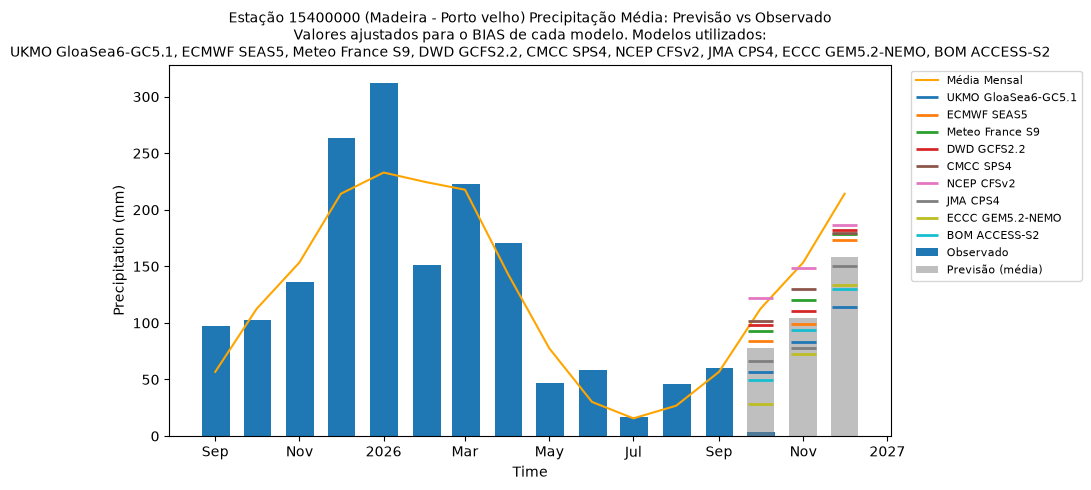

In [136]:
import matplotlib.pyplot as plt

model_names = list(models.keys())
model_colors = plt.get_cmap("tab10", len(model_names))

fig, ax = plt.subplots(figsize=(10, 5))
prec_avg_mean.plot(ax=ax, label="Média Mensal", color="orange")
ax.bar(prec_obs_mean["time"], prec_obs_mean, width=20.0, label="Observado")

obs_avg = prec_avg_mean.sel(time=prec_fcst_mean.step).to_numpy()
hindcast_avg = hindcast_mean.mean(dim="model")["tprate"].to_numpy()
fcst_bias = hindcast_avg - obs_avg

ax.bar(
    prec_fcst_mean["step"],
    prec_fcst_mean - fcst_bias,
    width=20.0,
    label="Previsão (média)",
    alpha=0.5,
    color="grey",
)

# Overlay each model's individual forecast as a short horizontal tick on the forecast bars,
# so the dispersion/range across models is visible at each lead time.
tick_halfwidth = pd.Timedelta(days=9)
steps = prec_fcst_by_model["step"].to_numpy()
for i, model_name in enumerate(model_names):
    model_values = prec_fcst_by_model.sel(model=model_name).to_numpy()

    for j, (step, value) in enumerate(zip(steps, model_values)):
        obs_avg = prec_avg_mean.sel(time=step).to_numpy()
        hindcast_avg = hindcast_mean.sel(model=model_name, step=step)["tprate"].to_numpy()
        model_bias = hindcast_avg - obs_avg

        ax.hlines(
            value - model_bias,
            xmin=step - tick_halfwidth,
            xmax=step + tick_halfwidth,
            color=model_colors(i),
            linewidth=2,
            label=model_name if j == 0 else None,
        )

model_list_str = ", ".join(model_names)
ax.set_title(
    f"Estação 15400000 (Madeira - Porto velho) Precipitação Média: Previsão vs Observado\nValores ajustados para o BIAS de cada modelo. Modelos utilizados:\n{model_list_str}",
    fontsize=10,
)
ax.set_xlabel("Time")
ax.set_ylabel("Precipitation (mm)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
fig.tight_layout()


In [1]:
prec_obs

NameError: name 'prec_obs' is not defined

In [137]:
prec_avg_mean

<xarray.DataArray 'precacum' (time: 16)> Size: 128B
array([ 56.73265503, 112.44033515, 153.44943794, 214.16112303,
       232.94096477, 224.40635556, 217.75795035, 143.55769589,
        77.60834923,  30.16370485,  15.63947132,  26.84385307,
        56.73265503, 112.44033515, 153.44943794, 214.16112303])
Coordinates:
  * time         (time) datetime64[ns] 128B 2025-09-01 2025-10-01 ... 2026-12-01
    spatial_ref  int64 8B 0

In [138]:
prec_fcst_mean - fcst_bias

<xarray.DataArray 'models' (step: 3)> Size: 24B
array([ 77.64807299, 103.94241945, 158.65896071])
Coordinates:
  * step         (step) datetime64[ns] 24B 2026-10-01 2026-11-01 2026-12-01
    spatial_ref  int64 8B 0
Attributes:
    long_name:   Time-mean total precipitation rate
    units:       meter / second
    level_type:  surface
    _earthkit:   {"message": {"__bytes_b64__": "R1JJQgAAiAEAAFCsSoD/gOQBAAAaC...